In [33]:
import pandas as pd
from sklearn.model_selection import ParameterGrid

import sys
sys.path.append("..")
from src.preprocessing import weigh_norm_densities, align_densities, df_to_densities
from src.utils import cv

In [2]:
# Dados
data_path = "../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df = pd.read_excel(returns_path, index_col="time")
df.head()

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-11-14,2025-11-17,2025-11-18,2025-11-19,2025-11-21,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28
time,,,,,,,,,,,,,,,,,,,,,
10:00:00,0.000011,-0.000372,-0.000035,0.007233,-0.001305,-0.000459,0.002388,0.002212,-0.008001,-0.000824,...,-0.000957,-0.002307,-0.003734,-0.005020,-0.001139,-0.000255,0.002339,0.004176,-0.000224,-0.000238
10:05:00,-0.002271,0.003372,0.001716,0.005538,0.000069,0.006429,0.002343,0.001918,-0.007582,-0.000413,...,-0.001522,0.000739,-0.000613,0.000306,-0.002021,-0.000810,0.001557,-0.001565,-0.000193,0.002906
10:10:00,-0.000582,0.002832,-0.000502,0.000739,0.000261,0.001891,0.000775,-0.001172,0.000216,-0.000432,...,0.000360,-0.000105,-0.000159,-0.000362,0.000092,0.001131,0.001170,0.000202,0.000556,0.000475
10:15:00,-0.001997,0.001091,0.000111,-0.000192,0.000407,-0.001392,-0.000477,-0.001526,0.000198,-0.001821,...,0.001121,-0.000284,0.003272,-0.001107,-0.001012,-0.000174,0.001002,0.001815,-0.000168,0.000973
10:20:00,-0.000037,-0.000505,-0.000327,-0.000580,-0.000436,-0.000405,0.001263,0.000676,-0.002667,0.001033,...,0.000449,0.000335,0.000853,0.000981,-0.000057,-0.000096,0.000832,0.001951,0.001060,-0.001004


In [10]:
param_grid_0 = [
    {'kernel': ['gaussian', 'epanechnikov'],
        'bandwidth': ['silverman', 'scott'],# 'cv'],
        'adaptive': [True, False]}, 
    {'kernel': ['t_student'], 
        'df': range(2,6),
        'bandwidth': ['silverman', 'scott'],# 'cv'],
        'adaptive': [True, False]}]

param_grid = list(ParameterGrid(param_grid_0))
l_params = len(param_grid)

In [ ]:
params_dict = {}
records = []
for i, params in enumerate(param_grid):
    print(f">>>Initiating parameters {i}/{l_params}")
    print(params)
    df_support, df_densities = df_to_densities(df, params, verbose=False)
    try:
        cv_measures = cv(df_densities, df_support, initial_window=245)
    except Exception:
        continue
    for m in cv_measures:
        record = {
            # density
            "density_model": "f_hat",
            
            # parameters
            "kernel": params["kernel"],
            "bandwidth": params["bandwidth"],
            "adaptive": params["adaptive"],

            # CV info
            "fold": m["fold"],
            "method": m["method"],

            # metrics
            "KLD": float(m["KLD"]),
            "JSD": float(m["JSD"]),
            "L_1": float(m["L_1"]),
            "L_2": float(m["L_2"]),
            "L_INFTY": float(m["L_INFTY"]),
        }

        records.append(record)
    # title = f"kernel: {params["kernel"]} | bandwidth: {params["bandwidth"]} | adaptive: {params["adaptive"]}"
    # params_dict[title] = cv_measures
    # params_dict[title]["density"] = "f_hat"

    print("/n/n")

results_df_1 = pd.DataFrame(records)

Initiating parameters 0/24
{'adaptive': True, 'bandwidth': 'silverman', 'kernel': 'gaussian'}
cv 0/4


c:\Users\user\anaconda3\envs\densities4risk\Lib\site-packages\scipy\interpolate\_interpolate.py:497: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\user\anaconda3\envs\densities4risk\Lib\site-packages\scipy\interpolate\_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


cv 1/4


c:\Users\user\anaconda3\envs\densities4risk\Lib\site-packages\scipy\interpolate\_interpolate.py:497: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\user\anaconda3\envs\densities4risk\Lib\site-packages\scipy\interpolate\_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


cv 2/4


...

cv 3/4


c:\Users\user\anaconda3\envs\densities4risk\Lib\site-packages\scipy\interpolate\_interpolate.py:497: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\user\anaconda3\envs\densities4risk\Lib\site-packages\scipy\interpolate\_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


/n/n
Initiating parameters 7/24
{'adaptive': False, 'bandwidth': 'scott', 'kernel': 'epanechnikov'}
cv 0/4


c:\Users\user\Projetos\densities4risk\notebooks\..\src\transformations.py:213: RuntimeWarning: divide by zero encountered in log
  lqd_temp = -np.log(dens[keep])
c:\Users\user\anaconda3\envs\densities4risk\Lib\site-packages\scipy\interpolate\_interpolate.py:500: RuntimeWarning: invalid value encountered in add
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
c:\Users\user\Projetos\densities4risk\notebooks\..\src\dynamicFPC.py:184: RuntimeWarning: invalid value encountered in subtract
  Ydev = Y - Ybar


Initiating parameters 8/24
{'adaptive': True, 'bandwidth': 'silverman', 'df': 2, 'kernel': 't_student'}
cv 0/4
cv 1/4
cv 2/4
cv 3/4
/n/n
Initiating parameters 9/24
{'adaptive': True, 'bandwidth': 'silverman', 'df': 3, 'kernel': 't_student'}
cv 0/4
cv 1/4
cv 2/4
cv 3/4
/n/n
Initiating parameters 10/24
{'adaptive': True, 'bandwidth': 'silverman', 'df': 4, 'kernel': 't_student'}
cv 0/4
cv 1/4
cv 2/4
cv 3/4
/n/n
Initiating parameters 11/24
{'adaptive': True, 'bandwidth': 'silverman', 'df': 5, 'kernel': 't_student'}
cv 0/4
cv 1/4
cv 2/4
cv 3/4
/n/n
Initiating parameters 12/24
{'adaptive': True, 'bandwidth': 'scott', 'df': 2, 'kernel': 't_student'}
cv 0/4
cv 1/4
cv 2/4
cv 3/4
/n/n
Initiating parameters 13/24
{'adaptive': True, 'bandwidth': 'scott', 'df': 3, 'kernel': 't_student'}
cv 0/4
cv 1/4
cv 2/4
cv 3/4
/n/n
Initiating parameters 14/24
{'adaptive': True, 'bandwidth': 'scott', 'df': 4, 'kernel': 't_student'}
cv 0/4
cv 1/4
cv 2/4
cv 3/4
/n/n
Initiating parameters 15/24
{'adaptive': True, '

In [14]:
records_norm = []
for i, params in enumerate(param_grid):
    print(f">>>Initiating parameters {i}/{l_params}")
    print(params)
    df_support, df_densities = df_to_densities(df, params, verbose=False)
    df_density_norm = weigh_norm_densities(df_densities, df_support.iloc[:,0])

    try:
        cv_measures = cv(df_density_norm, df_support, initial_window=245)
    except Exception:
        print(f"\t [ERROR] Problem for {params}. Continuing...")
        continue
    for m in cv_measures:
        record = {
            # density
            "density_model": "f_star",
            
            # parameters
            "kernel": params["kernel"],
            "bandwidth": params["bandwidth"],
            "adaptive": params["adaptive"],

            # CV info
            "fold": m["fold"],
            "method": m["method"],

            # metrics
            "KLD": float(m["KLD"]),
            "JSD": float(m["JSD"]),
            "L_1": float(m["L_1"]),
            "L_2": float(m["L_2"]),
            "L_INFTY": float(m["L_INFTY"]),
        }

        records.append(record)

results_df_2 = pd.DataFrame(records_norm)

>>>Initiating parameters 0/24
{'adaptive': True, 'bandwidth': 'silverman', 'kernel': 'gaussian'}
cv 0/4


c:\Users\user\anaconda3\envs\densities4risk\Lib\site-packages\scipy\interpolate\_interpolate.py:497: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\user\anaconda3\envs\densities4risk\Lib\site-packages\scipy\interpolate\_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


cv 1/4


c:\Users\user\anaconda3\envs\densities4risk\Lib\site-packages\scipy\interpolate\_interpolate.py:497: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\user\anaconda3\envs\densities4risk\Lib\site-packages\scipy\interpolate\_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


cv 2/4


...

cv 2/4


c:\Users\user\Projetos\densities4risk\notebooks\..\src\transformations.py:213: RuntimeWarning: divide by zero encountered in log
  lqd_temp = -np.log(dens[keep])


cv 3/4
	 [ERROR] Problem for {'adaptive': False, 'bandwidth': 'scott', 'kernel': 'epanechnikov'}. Continuing...
>>>Initiating parameters 8/24
{'adaptive': True, 'bandwidth': 'silverman', 'df': 2, 'kernel': 't_student'}


c:\Users\user\Projetos\densities4risk\notebooks\..\src\transformations.py:213: RuntimeWarning: divide by zero encountered in log
  lqd_temp = -np.log(dens[keep])
c:\Users\user\Projetos\densities4risk\notebooks\..\src\dynamicFPC.py:184: RuntimeWarning: invalid value encountered in subtract
  Ydev = Y - Ybar


cv 0/4
cv 1/4
cv 2/4
cv 3/4
>>>Initiating parameters 9/24
{'adaptive': True, 'bandwidth': 'silverman', 'df': 3, 'kernel': 't_student'}
cv 0/4
cv 1/4
cv 2/4
cv 3/4
>>>Initiating parameters 10/24
{'adaptive': True, 'bandwidth': 'silverman', 'df': 4, 'kernel': 't_student'}
cv 0/4
cv 1/4
cv 2/4
cv 3/4
>>>Initiating parameters 11/24
{'adaptive': True, 'bandwidth': 'silverman', 'df': 5, 'kernel': 't_student'}
cv 0/4
cv 1/4
cv 2/4
cv 3/4
>>>Initiating parameters 12/24
{'adaptive': True, 'bandwidth': 'scott', 'df': 2, 'kernel': 't_student'}
cv 0/4
cv 1/4
cv 2/4
cv 3/4
>>>Initiating parameters 13/24
{'adaptive': True, 'bandwidth': 'scott', 'df': 3, 'kernel': 't_student'}
cv 0/4
cv 1/4
cv 2/4
cv 3/4
>>>Initiating parameters 14/24
{'adaptive': True, 'bandwidth': 'scott', 'df': 4, 'kernel': 't_student'}
cv 0/4
cv 1/4
cv 2/4
cv 3/4
>>>Initiating parameters 15/24
{'adaptive': True, 'bandwidth': 'scott', 'df': 5, 'kernel': 't_student'}
cv 0/4
cv 1/4
cv 2/4
cv 3/4
>>>Initiating parameters 16/24
{'adap

In [15]:
results_df_1 = pd.DataFrame(records)
results_df_2 = pd.DataFrame(records_norm)
results_df = pd.concat([results_df_1, results_df_2], axis=0, ignore_index=True)

In [16]:
results_df.to_excel("../data/processed/cv_density_estimation_minor.xlsx", index=False)

In [17]:
metrics = ["KLD", "JSD", "L_1", "L_2", "L_INFTY"]

mean_df = (
    results_df
    .groupby(["density_model", "kernel", "bandwidth", "adaptive"])[metrics]
    .mean()
    .reset_index()
)
for m in metrics:
    best_value = mean_df[m].min()
    mean_df[f"win_{m}"] = mean_df[m] == best_value

win_cols = [f"win_{m}" for m in metrics]

mean_df["n_wins"] = mean_df[win_cols].sum(axis=1)

best_overall = mean_df.sort_values("n_wins", ascending=False).iloc[0]
best_overall

density_model       f_star
kernel           t_student
bandwidth            scott
adaptive             False
KLD               0.170664
JSD               0.011834
L_1               0.163028
L_2               0.048031
L_INFTY           0.026564
win_KLD              False
win_JSD              False
win_L_1               True
win_L_2               True
win_L_INFTY           True
n_wins                   3
Name: 13, dtype: object

## Best model

In [43]:
import plotly.express as px
from src.forecasting import run_forecaster, train_test_split, overall_measures, expanding_window_cv, slice_fold
from src.transformations import (
                            obtain_densities, 
                            mLQDT,
                            obtain_densities_from_lqd
                            )
from src.dynamicFPC import K_dFPC
import pmdarima as pm
import matplotlib.pyplot as plt

In [28]:
def px_select_menu(fig):
    fig.update_layout(
        updatemenus=[
            dict(
                type="buttons",
                direction="left",
                buttons=list([
                    dict(
                        args=["visible", "legendonly"],
                        label="Deselect All",
                        method="restyle"
                    ),
                    dict(
                        args=["visible", True],
                        label="Select All",
                        method="restyle"
                    )
                ]),
                pad={"r": 10, "t": 10},
                showactive=False,
                x=1,
                xanchor="right",
                y=1.1,
                yanchor="top"
            ),
        ]
    )

In [20]:
params = {
    "kernel": "t_student",
    "bandwidth": "scott",
    "adaptive": False,
    "df": 3}

In [21]:
df_support_final, df_densities_final = df_to_densities(df, params, verbose=False)

In [30]:
fig = px.line(
    df_densities_final,
    color_discrete_sequence=["#1f77b4"]
)

fig.update_traces(
    opacity=0.25,          # alpha
    line=dict(width=1)    # thin lines
)

fig.update_layout(
    legend=dict(
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top"
    ),
    margin=dict(r=160),  # make room for the legend
    title=f"{params}"
)

px_select_menu(fig)


fig.show()

In [32]:
horizon = 10
Y_train_support, Y_train, Y_test_support, Y_test = train_test_split(
                                                                df_densities_final, 
                                                                df_support_final,
                                                                train_size=horizon)
Y_train.head()

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-10-31,2025-11-03,2025-11-04,2025-11-05,2025-11-06,2025-11-07,2025-11-10,2025-11-11,2025-11-12,2025-11-13
-0.018871,0.001171,0.001428,0.000682,0.002856,0.000621,0.001836,0.000804,0.019845,0.006565,0.000554,...,0.000574,0.000834,0.000219,0.000679,0.000572,0.000659,0.001274,0.001954,0.000501,0.001990
-0.018718,0.001210,0.001476,0.000704,0.002950,0.000642,0.001897,0.000830,0.020511,0.006810,0.000573,...,0.000593,0.000862,0.000227,0.000701,0.000591,0.000681,0.001316,0.002018,0.000518,0.002056
-0.018564,0.001251,0.001525,0.000728,0.003049,0.000663,0.001960,0.000858,0.021206,0.007067,0.000592,...,0.000613,0.000891,0.000234,0.000725,0.000611,0.000704,0.001360,0.002085,0.000535,0.002126
-0.018411,0.001293,0.001577,0.000753,0.003151,0.000686,0.002026,0.000887,0.021929,0.007337,0.000612,...,0.000634,0.000921,0.000242,0.000749,0.000631,0.000728,0.001406,0.002155,0.000553,0.002198
-0.018258,0.001338,0.001631,0.000778,0.003258,0.000710,0.002095,0.000917,0.022685,0.007621,0.000633,...,0.000656,0.000952,0.000250,0.000774,0.000653,0.000752,0.001454,0.002228,0.000572,0.002274


In [42]:
# mLQDT
bovespa_mLQDT = mLQDT(
                    Y_train,
                    Y_train_support
                )
bovespa_mLQDT.densities_to_lqdensities(verbose=False)
df_lqds = bovespa_mLQDT.lqd.iloc[1:-1,:]
df_lqds_support = bovespa_mLQDT.lqd_support[1:-1]

# KdFPC
KdFPC_kwargs = {
    "lag_max": 5,
    "alpha": 0.10,
    "du": 0.05,
    "B": 1000,
    "p": 5,
    "u": df_lqds_support,
    "select_ncomp": False,
    "dimension": 2
}
KdFPC_model = K_dFPC(df_lqds.values)
KdFPC_model.fit(**KdFPC_kwargs)
k_scores = KdFPC_model.etahat.real.T

# Forecasting c+h
maxlags_  = 10
criteria_ = 'bic'
k_etahat_fc = run_forecaster(k_scores, maxlags_, criteria_, horizon)
model = pm.auto_arima(
    bovespa_mLQDT.c,                         # univariate series
    seasonal=False,            # True if SARIMA
    error_action='ignore',     # ignore non-invertible models
    suppress_warnings=True,
    information_criterion='bic',
    trace=False
)

# Forecast h steps ahead
c_forecast, conf_int = model.predict(n_periods=horizon, return_conf_int=True)
k_curve_forecast = KdFPC_model.predict(k_etahat_fc)
df_k_forecast = pd.DataFrame(k_curve_forecast, columns=Y_test.columns)

# Backwards transformation
kle_bkw_supports, kle_bkw_densities = obtain_densities_from_lqd(
                                                            df_k_forecast,
                                                            bovespa_mLQDT.lqd_support,
                                                            c_forecast,
                                                            verbose=False
                                                            )

# Align densities
df_supp, df_f_kle, df_kle_fhat = align_densities(
                                Y_test_support, 
                                Y_test, 
                                kle_bkw_supports, 
                                kle_bkw_densities, 
                                kle_bkw_densities.columns)

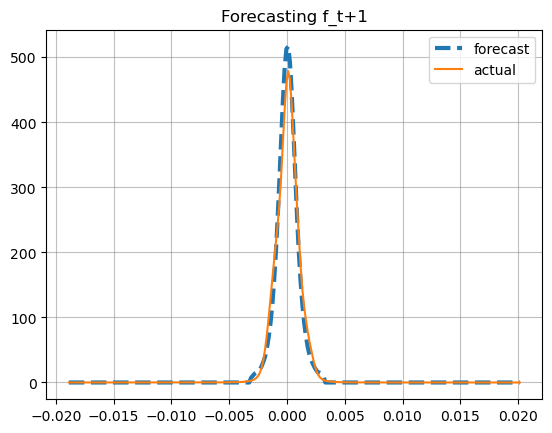

In [54]:
t=0

plt.figure()

plt.plot(df_supp.iloc[:,t], df_kle_fhat.iloc[:,t], linestyle="--", linewidth=3, label="forecast")
plt.plot(df_supp.iloc[:,t], df_f_kle.iloc[:,t], label="actual")

plt.legend()
plt.grid(True, alpha=.5, color="gray")
plt.title(f"Forecasting f_t+{t+1}")
plt.show()